# Turbulent transport with TGLF, and whether a neural surrogate may stand in for it

TGLF is the quasilinear turbulent-transport model of the GACODE suite, and running
it on one VEST discharge is the easy half of this notebook. The other half is the
question people actually ask of a surrogate: **a published TGLF-NN network will
return a flux for any input you hand it -- how do you know whether to believe it?**

That question has an answer here, and the answer for VEST is no. Not one of the
public TGLF-NN families applies to this plasma, and the reason is a single number
the notebook computes in section 1 and never lets go of.

Three kinds of number are kept apart throughout, because conflating them is the
easiest way to overstate what a calculation shows:

| | |
| --- | --- |
| **Measured** | electron density and temperature, ion temperature -- fitted from Thomson and CX |
| **Modelling assumption** | the effective charge and the impurity that carries it, where to truncate, the saturation rule, and the 3-sigma threshold that decides "in domain" |
| **Computed** | the local TGLF input, the domain audit, and the gyro-Bohm fluxes |

**What runs without what.** There are two independent capabilities here, not one
chain. The native run needs a built GACODE; the surrogate needs model artifacts;
and the audit -- the part that answers the question above -- needs *neither a
solver nor a neural-network runtime*. With nothing installed at all, sections 1
and 2 still compute the number the whole argument rests on.


## 0. Setup

TGLF is a **local** code, which is the first thing that separates it from NEO.
NEO reads `input.gacode` and solves a profile; TGLF reads 137 dimensionless
quantities at *one flux surface* and knows nothing about the rest of the plasma.
So there is no `input.gacode` in a TGLF run directory, and a profile means
running it once per surface.

VAFT resolves `$GACODEHOME/tglf/bin/tglf`, the same `$XHOME` convention CHEASE,
EFIT, GPEC, TES and NUBEAM follow -- with the difference that **GACODE builds in
place**, so `$GACODEHOME` is the source checkout itself and each suite member
carries its own `bin`. It also needs `$GACODE_PLATFORM`, the tag the tree was
built with.

The surrogate needs neither. It needs pretrained ONNX ensembles, which VAFT does
not ship and does not download: point `$TURBULENTTRANSPORTHOME` at a
TurbulentTransport.jl checkout, or let VAFT find one in an existing Julia depot.
`onnxruntime` is an optional extra and is needed only to *run* a network.

Whatever is missing is reported and skipped -- nothing below raises. The kinetic
state is packaged: `vaft/data/kineticEfit/ods_48224_300ms.json`, shot 48224 at
300 ms, a **repository-only** asset that is not shipped in the wheel.


In [ ]:
import contextlib
import importlib.util
import os
import tempfile
from pathlib import Path

try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
from omas import load_omas_json

import vaft
from vaft.code.gacode import find_gacode_executable, tglf
from vaft.code.gacode.inputs import prepare_gacode_profile
from vaft.code.gacode.tglf import surrogate

plt.rcParams["figure.dpi"] = 110

# Modelling assumptions, named here rather than buried in a call below.
#
# Z_EFF / IMPURITY: the packaged state carries no zeff profile. 2.0 is the value
#   the rest of VAFT's ohmic estimates use, and naming carbon is what makes it
#   real -- the converter gives the main ion and the impurity the densities that
#   satisfy quasi-neutrality and Z_eff together (n_H = 0.8 n_e, n_C = n_e/30)
#   rather than writing 2 into a column and handing the solver pure hydrogen.
# RHO_MAX: the fitted profiles reach exactly zero at the boundary and GACODE
#   takes logarithmic gradients, so the grid must stop short of it.
# SAT_RULE / USE_BPER: SAT3 with the perpendicular magnetic perturbation, chosen
#   to match the `sat3_em_*` families the audit is about. Comparing a SAT3-trained
#   network against a SAT0 run would put a difference in the table that belongs to
#   the notebook rather than to the physics.
# THRESHOLD: how many standard deviations from a model's training mean still
#   counts as "in domain". A proxy, not a bound -- see section 4.
Z_EFF = 2.0
IMPURITY = "C"
RHO_MAX = 0.95
SAT_RULE = 3
THRESHOLD = 3.0

# Five surfaces spanning the same band the NEO notebook uses, so the two GACODE
# transport notebooks can be read against each other.
RADII = (0.2, 0.35, 0.5, 0.65, 0.8)
REFERENCE_RHO = 0.5
FAMILY = "sat3_em_d3d+mastu+nstx_azf-1"

SAMPLE = vaft.data.data_path("kineticEfit/ods_48224_300ms.json")
CONFIG = tglf.TGLFConfig(
    sat_rule=SAT_RULE, use_bper=True, platform=os.environ.get("GACODE_PLATFORM")
)

# find_gacode_executable returns None when nothing is configured, and raises when
# $GACODEHOME is set but the tree is not built -- an unbuilt checkout is a
# different problem from an absent one, and says so.
try:
    EXECUTABLE = find_gacode_executable(CONFIG, "tglf")
except (FileNotFoundError, PermissionError) as error:
    print(f"GACODE is configured but TGLF is not usable:\n  {error}\n")
    EXECUTABLE = None
HAVE_GACODE = EXECUTABLE is not None

# Resolving a model reads directories; it does not import onnxruntime. Checking
# for the runtime with find_spec rather than importing it keeps a heavy native
# library out of every run of this notebook that never predicts anything.
MODELS = surrogate.available_models()
HAVE_MODELS = bool(MODELS)
HAVE_RUNTIME = importlib.util.find_spec("onnxruntime") is not None

print(f"sample       {SAMPLE.name}  ({'present' if SAMPLE.exists() else 'MISSING'})")
print(f"surfaces     r/a = {RADII}")
print(f"assumptions  Z_eff = {Z_EFF} as a {IMPURITY} impurity, rho_max = {RHO_MAX},"
      f" SAT_RULE = {SAT_RULE}")
print(f"executable   {EXECUTABLE}")
print(f"models       {len(MODELS)} ONNX families resolvable")
print(f"onnxruntime  {'present' if HAVE_RUNTIME else 'absent'}")

if not HAVE_GACODE:
    print(
        "\nTGLF was not found. Set $GACODEHOME to a built GACODE checkout and"
        " $GACODE_PLATFORM\nto the tag it was built with, and note that"
        " install/gacode/macos.sh builds `neo` alone\nunless you pass"
        " --codes neo,tglf. Sections 5 and 6 report what they would show and skip."
    )
if not HAVE_MODELS:
    print(
        "\nNo TGLF-NN models resolved. Set $TURBULENTTRANSPORTHOME to a"
        " TurbulentTransport.jl\ncheckout, or install the package into a Julia depot;"
        " VAFT vendors no weights and\ndownloads nothing. Sections 3, 4 and 7 report"
        " what they would show and skip."
    )


sample       ods_48224_300ms.json  (present)
surfaces     r/a = (0.2, 0.35, 0.5, 0.65, 0.8)
assumptions  Z_eff = 2.0 as a C impurity, rho_max = 0.95, SAT_RULE = 3
executable   ~/git/gacode/tglf/bin/tglf
models       14 ONNX families resolvable
onnxruntime  present


## 1. The plasma, and the ratio that decides the answer

VEST 48224 at 300 ms is a small, cold, ohmically heated spherical tokamak
discharge. The property that matters for everything below is that **its ions are
an order of magnitude colder than its electrons**, because an ohmic plasma that
lasts about ten milliseconds has no time to equilibrate them.

That ratio is not a defect in the data. `vest.yaml` records `ti_te_ratio` as
0.17 +/- 0.08, status `inferred`: a pressure-matching coefficient over the fitted
profiles, cross-checked independently at 0.170 +/- 0.010 by regressing measured
Thomson `T_e` against the charge-exchange `T_i` fit, and stable at 0.163-0.171
across mapping gfile, fit degree and pairing direction. It also records a known
trend -- the early 299 ms slices sit near 0.28 against the 300-301 ms cluster
near 0.14 -- so some of the spread is slice selection.

The number below is a different, *local* quantity: `TAUS`, the ratio TGLF and
every surrogate actually see at one surface. This section computes it. Nothing
here needs GACODE or a model.


In [ ]:
ods = load_omas_json(str(SAMPLE), consistency_check=False)
profile = prepare_gacode_profile(ods, rho_max=RHO_MAX, z_eff=Z_EFF, impurity=IMPURITY)

# One local input per surface. This is the contract both backends consume.
LOCALS = {rho: tglf.prepare_tglf_input(profile, rho) for rho in RADII}

print(f"species      {list(LOCALS[REFERENCE_RHO].names)}  (electrons first, as TGLF indexes them)")
print(f"grid         {profile.n_exp} points, truncated at rho = {RHO_MAX}")
print()
print("  r/a    T_i/T_e       q      beta_e      nu_ee   species")
for rho, local in LOCALS.items():
    print(f"  {rho:<5.2f} {local.taus[1]:9.4f} {local.q_loc:8.3f}"
          f" {local.betae:10.4g} {local.xnue:10.4g}   {local.n_species}")

TI_TE_AT_HALF_RADIUS = float(LOCALS[REFERENCE_RHO].taus[1])
print(f"\nT_i/T_e at r/a = {REFERENCE_RHO} is {TI_TE_AT_HALF_RADIUS:.3f}"
      f"  -- ions {1 / TI_TE_AT_HALF_RADIUS:.0f}x colder than electrons")

# What the state could not supply. These reach input.tglf as TGLF's own defaults,
# and the provenance is the only thing that separates a default from a choice:
# a reader of the file alone sees VEXB_SHEAR=0.0 and cannot know nobody measured it.
print(f"\nrecorded unavailable: {LOCALS[REFERENCE_RHO].missing()}")
print("  zeta_loc / s_zeta_loc  no squareness on the profile; the surface is taken"
      " as elliptic")
print("  vexb_shear             no w0 on the profile, so no ExB shear can be derived")


species      ['e', 'H+', 'C6+']  (electrons first, as TGLF indexes them)
grid         123 points, truncated at rho = 0.95

  r/a    T_i/T_e       q      beta_e      nu_ee   species
  0.20     0.1700    1.878   0.003503      3.533   3
  0.35     0.1136    1.885   0.003286      2.058   3
  0.50     0.0866    1.965   0.002617      1.187   3
  0.65     0.0944    2.183   0.001429     0.7699   3
  0.80     0.1316    2.747  0.0003827       0.62   3

T_i/T_e at r/a = 0.5 is 0.087  -- ions 12x colder than electrons

recorded unavailable: ('zeta_loc', 's_zeta_loc', 'vexb_shear')
  zeta_loc / s_zeta_loc  no squareness on the profile; the surface is taken as elliptic
  vexb_shear             no w0 on the profile, so no ExB shear can be derived


## 2. One contract, two backends

`tglf_parameters()` produces the `KEY=VALUE` settings `input.tglf` is written
from. The surrogate's feature vector is assembled from **those same keys**,
selected and ordered by the model's own `xnames`, with a `_log10` suffix asking
for the base-10 logarithm of the key with the suffix removed.

That is the whole reason a surrogate here is a surrogate *of this contract* and
not a parallel implementation: the two backends cannot drift apart without the
shared contract changing.


In [ ]:
parameters = tglf.tglf_parameters(LOCALS[REFERENCE_RHO], CONFIG)
print(f"{len(parameters)} keys written to input.tglf")
print()
print("the handful the audit will turn on:")
for key in ("TAUS_2", "TAUS_3", "AS_2", "AS_3", "ZS_3", "RMIN_LOC", "RMAJ_LOC",
            "Q_LOC", "BETAE", "XNUE", "DEBYE", "ZEFF"):
    print(f"  {key:10s} {parameters[key]:>12.5g}")
print()
print("and the three that rest on a default rather than on the state:")
for key in ("ZETA_LOC", "S_ZETA_LOC", "VEXB_SHEAR"):
    print(f"  {key:10s} {parameters[key]:>12.5g}   (recorded unavailable)")


137 keys written to input.tglf

the handful the audit will turn on:
  TAUS_2         0.086648
  TAUS_3         0.086648
  AS_2                0.8
  AS_3           0.033333
  ZS_3                  6
  RMIN_LOC            0.5
  RMAJ_LOC         1.5073
  Q_LOC            1.9653
  BETAE         0.0026168
  XNUE             1.1874
  DEBYE          0.006448
  ZEFF                  2

and the three that rest on a default rather than on the state:
  ZETA_LOC              0   (recorded unavailable)
  S_ZETA_LOC            0   (recorded unavailable)
  VEXB_SHEAR            0   (recorded unavailable)


## 3. Which public models are on this machine

VAFT vendors no weights and downloads nothing. It finds artifacts you already
have, in this order: an explicit path, then `model_dir=`, then
`$TURBULENTTRANSPORTHOME`, then an existing Julia depot. A family name held by
two roots with *differing* bytes is refused rather than chosen between -- upstream
versions the networks behind a stable name, and its own `models/SEMVER` says a
minor bump can mean different TGLF settings behind an unchanged family name.

Two caveats about the list below. Upstream publishes ONNX for only 14 of its
roughly 100 families -- the rest are Julia `.bson` and unreadable from Python --
and the `*_gknn*` families take a base model's own fluxes as *inputs*. Those are
two-stage correction networks, not drop-in surrogates, and the refusal you see
below is content rather than an error.

**This table is what this machine resolved, not a catalogue.** A different
checkout lists different rows.


In [ ]:
RESOLVED = {}
if HAVE_MODELS:
    print(f"{'family':38s} {'sat':>3s} {'em':>3s} {'ensemble':>9s} {'version':>8s}"
          f"  {'via':<14s} alt")
    for name in sorted(MODELS):
        identity = surrogate.resolve_model(name)
        try:
            metadata = surrogate.load_metadata(identity)
        except surrogate.ModelContractError:
            print(f"{name:38s}  refused: two-stage correction network, its inputs"
                  f" include a base model's own fluxes")
            continue
        RESOLVED[name] = (identity, metadata)
        print(f"{name:38s} {identity.sat_rule!s:>3s}"
              f" {('em' if identity.electromagnetic else 'es'):>3s}"
              f" {identity.ensemble_size:>9d} {identity.upstream_version or '-':>8s}"
              f"  {identity.resolved_by:<14s} {len(identity.alternatives)}")
    print(f"\n{len(RESOLVED)} usable, {len(MODELS) - len(RESOLVED)} refused as two-stage")
    print("`alt` counts other roots holding a byte-identical copy; a differing copy"
          " would have\nbeen refused rather than listed.")
else:
    print("Would list every TGLF-NN family found on this machine, with its"
          " saturation rule,\nits training devices, its ensemble size and the upstream"
          " version it came from.")


family                                 sat  em  ensemble  version  via            alt
sat0quench_em_mastu_azf+1                0  em        20    1.1.4  julia depot    1
sat0quench_es_ukstep_azf+1               0  es        20    1.1.4  julia depot    1
sat1_em_mastu_azf-1                      1  em        20    1.1.4  julia depot    1
sat1_es_ukstep_azf-1                     1  es        20    1.1.4  julia depot    1
sat1geo_es_nstx_azf-1                    1  es        20    1.1.4  julia depot    1
sat2_em_mastu_azf-1                      2  em        20    1.1.4  julia depot    1
sat2_es_nstx_azf-1                       2  es        20    1.1.4  julia depot    1
sat2_es_ukstep_azf-1                     2  es        20    1.1.4  julia depot    1
sat3_em_d3d+mastu+nstx_azf-1             3  em        20    1.1.4  julia depot    1
sat3_em_d3d+mastu+nstx_azf-1_gknn31     refused: two-stage correction network, its inputs include a base model's own fluxes
sat3_em_d3d+mastu_azf-1           

## 4. Does any of them apply to VEST?

This is the centrepiece, and it comes **before** any prediction. Deciding whether
a model applies is a question about the input and the training moments, so it
needs neither GACODE nor `onnxruntime` -- and asking it first is the difference
between a result and a number.

What the measure is, exactly: a standard-deviation distance from each model's own
training mean, `(x - xm) / xsigma`, per input channel. It is **not** a containment
test. The true per-input bounds live inside the upstream Julia `.bson`, and the
ONNX distribution ships only the moments -- which is why every audit reports
`bounds_available = False`. Read `in_domain` as "nothing is far from what this
model saw", never as a guarantee.

A violation does not mean the network fails. It means the network will return a
finite, plausible-looking number with nothing behind it.


In [ ]:
AUDITS = {}
REFERENCE_FAMILY = None


# The channel a family is furthest out on, or None when it is in domain.
# `violations` is empty exactly when nothing exceeded the threshold -- the
# outcome section 10 names as the one that would change the conclusion, so it
# must not be the case that crashes the notebook.
def worst_channel(audit):
    return audit.violations[0] if audit.violations else None


if RESOLVED:
    for name, (identity, metadata) in RESOLVED.items():
        AUDITS[name] = surrogate.audit_training_domain(
            LOCALS[REFERENCE_RHO], identity, metadata,
            config=CONFIG, threshold=THRESHOLD,
        )
    print(f"{'family':38s} {'max|z|':>7s} {'inputs':>7s} {'bad':>4s}  worst channels")
    for name, audit in sorted(AUDITS.items(), key=lambda kv: kv[1].max_abs_z):
        print(f"{name:38s} {audit.max_abs_z:7.2f} {len(audit.z_scores):7d}"
              f" {len(audit.violations):4d}  {', '.join(audit.violations[:3])}")

    best = min(AUDITS, key=lambda n: AUDITS[n].max_abs_z)
    # FAMILY is this notebook's preferred illustration, not a guarantee: a
    # checkout carrying only some families still has an audit to report, so fall
    # back to whichever one came closest rather than raising on a missing key.
    REFERENCE_FAMILY = FAMILY if FAMILY in RESOLVED else best
    if REFERENCE_FAMILY != FAMILY:
        print(f"({FAMILY} is not in this checkout; illustrating with"
              f" {REFERENCE_FAMILY}, the closest one that is)")
    print(f"\nbest available: {AUDITS[best].summary()}")
    print(f"in_domain         {AUDITS[best].in_domain}")
    print(f"bounds_available  {AUDITS[best].bounds_available}"
          "   (a sigma distance, not containment)")
    print(f"assumed           {AUDITS[best].assumed}")
    print("  reported, not refused: input.tglf carries the same defaults into the"
          " native\n  solver, and a surrogate stricter than the code it stands in for"
          " is no longer a\n  surrogate of it.")

    identity, metadata = RESOLVED[REFERENCE_FAMILY]
    if "TAUS_2" in metadata.xnames:
        index = list(metadata.xnames).index("TAUS_2")
        print(f"\nThe whole story, in four numbers ({REFERENCE_FAMILY}):")
        print(f"  training mean TAUS_2    {metadata.xm[index]:.3f}"
              f" +/- {metadata.xsigma[index]:.3f}")
        print(f"  VEST 48224 at r/a={REFERENCE_RHO}   {TI_TE_AT_HALF_RADIUS:.3f}")
        print(f"  z                       "
              f"{AUDITS[REFERENCE_FAMILY].z_scores['TAUS_2']:+.2f}")

    ukstep = [n for n in AUDITS if "ukstep" in n]
    if ukstep:
        print("\nAnd a second, independent mismatch. TAUS is in every family's"
              " violation set,\nbut for the UKSTEP families it is not the largest:")
        for name in sorted(ukstep):
            audit = AUDITS[name]
            line = (f"  {name:32s} max|z| {audit.max_abs_z:6.1f}"
                    f" on {worst_channel(audit) or 'nothing'}")
            ratio = audit.z_scores.get("TAUS_2")
            if ratio is not None:
                line += f", TAUS_2 at {ratio:+.1f}"
            print(line)
        print("  AS_3 and ZS_3 are the impurity density fraction and charge. Fixing"
              " the\n  temperature ratio would not rescue those, and vice versa: the"
              " refusal is\n  over-determined rather than one fragile coincidence.")
else:
    print("Would audit every resolvable TGLF-NN family against this plasma --"
          " without\nonnxruntime and without a prediction, because whether a model"
          " applies is a\nquestion about the input and the training moments alone.")

HAVE_AUDIT = bool(AUDITS)


family                                  max|z|  inputs  bad  worst channels
sat3_em_d3d+mastu_azf-1                   4.44      31    2  TAUS_2, TAUS_3
sat3_em_d3d+mastu+nstx_azf-1              4.48      31    2  TAUS_3, TAUS_2
sat3_es_nstx_azf-1                        4.91      31    2  TAUS_3, TAUS_2
sat1geo_es_nstx_azf-1                     5.17      31    2  TAUS_3, TAUS_2
sat2_es_nstx_azf-1                        5.20      31    2  TAUS_3, TAUS_2
sat1_em_mastu_azf-1                       8.16      29    2  TAUS_2, TAUS_3
sat2_em_mastu_azf-1                       8.60      29    2  TAUS_2, TAUS_3
sat0quench_em_mastu_azf+1                 8.99      29    2  TAUS_2, TAUS_3
sat3_em_mastu_azf-1                       9.59      29    2  TAUS_2, TAUS_3
sat0quench_es_ukstep_azf+1               41.65      26    5  AS_3, ZS_3, DEBYE_log10
sat2_es_ukstep_azf-1                     43.46      26    9  AS_3, ZS_3, DEBYE_log10
sat1_es_ukstep_azf-1                     43.77      26    9  AS_3, ZS_

## 5. The figure: how far outside, and where

The left panel is the finding, and it is drawn on any machine: VEST's local
`T_i/T_e` against the band a trained network expects. The right panel ranks the
families by how far this plasma sits from each, and needs the artifacts.

Both are drawn with plain matplotlib rather than through VAFT's plot catalog.
The catalog's entry point takes an ODS and reads an IDS out of it, and TGLF
fluxes reach no IDS until the `core_transport` projection of issue #553 section
14 -- while a `DomainAudit` has no IDS representation at all and never will, being
a property of the model artifacts on this machine rather than of the plasma. The
semantic recipe belongs with the mapping that gives it something to read.


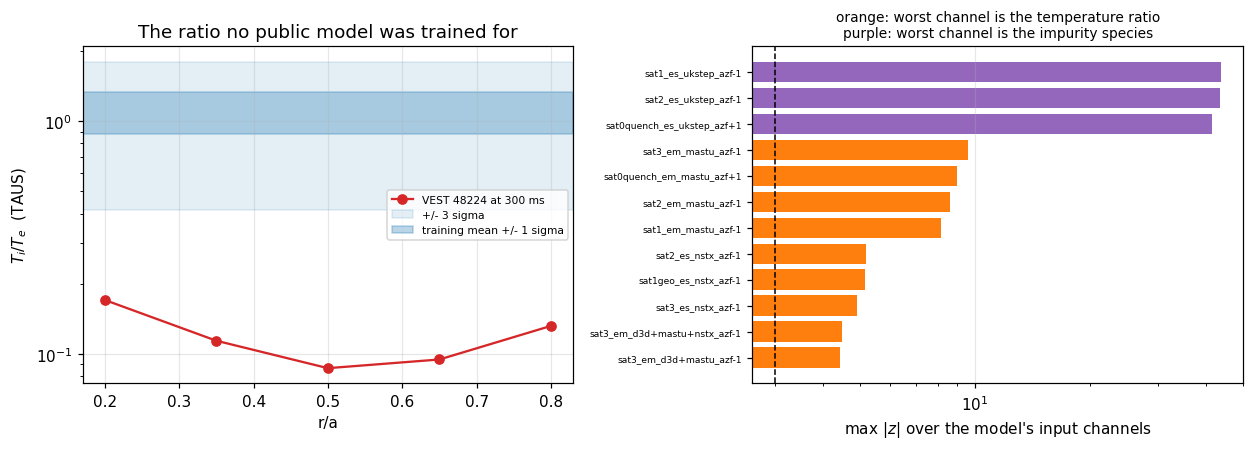

In [ ]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

radii = np.array(RADII)
ratios = np.array([LOCALS[rho].taus[1] for rho in RADII])
left.semilogy(radii, ratios, "o-", color="C3", label="VEST 48224 at 300 ms")
band = None
if HAVE_AUDIT:
    _, metadata = RESOLVED[REFERENCE_FAMILY]
    if "TAUS_2" in metadata.xnames:
        index = list(metadata.xnames).index("TAUS_2")
        band = (float(metadata.xm[index]), float(metadata.xsigma[index]))
if band is not None:
    mean, sigma = band
    left.axhspan(mean - THRESHOLD * sigma, mean + THRESHOLD * sigma,
                 color="C0", alpha=0.12, label=f"+/- {THRESHOLD:g} sigma")
    left.axhspan(mean - sigma, mean + sigma, color="C0", alpha=0.30,
                 label="training mean +/- 1 sigma")
left.set_xlabel("r/a")
left.set_ylabel("$T_i / T_e$  (TAUS)")
left.set_title("The ratio no public model was trained for")
left.legend(fontsize=7, loc="best")
left.grid(alpha=0.3)

if HAVE_AUDIT:
    order = sorted(AUDITS, key=lambda n: AUDITS[n].max_abs_z)
    values = [AUDITS[n].max_abs_z for n in order]
    # Green would mean a family that covers this plasma. None does today, and
    # the colour exists so that the figure shows it rather than raising if one
    # ever did.
    def _colour(audit):
        channel = worst_channel(audit)
        if channel is None:
            return "C2"
        return "C1" if channel.startswith("TAUS") else "C4"

    colours = [_colour(AUDITS[n]) for n in order]
    right.barh(range(len(order)), values, color=colours)
    right.set_yticks(range(len(order)))
    right.set_yticklabels(order, fontsize=6)
    right.axvline(THRESHOLD, color="k", ls="--", lw=1)
    right.set_xscale("log")
    right.set_xlabel("max $|z|$ over the model's input channels")
    right.set_title("orange: worst channel is the temperature ratio\n"
                    "purple: worst channel is the impurity species", fontsize=9)
    right.grid(alpha=0.3, axis="x")
else:
    right.text(0.5, 0.5, "Would rank every resolvable family by how far\nthis plasma"
                         " sits from its training distribution.",
               ha="center", va="center", fontsize=9, transform=right.transAxes)
    right.set_axis_off()

fig.tight_layout()
plt.show()


## 6. The native run

`run_tglf_case` stages only `input.tglf` -- no `input.gacode`, because TGLF does
not read one and leaving a copy in the directory would suggest the run depended
on it.

One behaviour worth stating because it is the opposite of what an exit code
usually means: TGLF's launcher creates `out.tglf.run` **before** the solve starts,
and TGLF reports its own input errors by writing them there. So neither a zero
exit status nor the presence of output proves anything. `check=False` below is
deliberate -- the outcome is read from `TglfOutputs.solved`, which requires the
gyro-Bohm fluxes to exist and to be finite.


In [ ]:
_cleanup = contextlib.ExitStack()
RUN_DIR = None
RESULTS = {}

if HAVE_GACODE:
    RUN_DIR = Path(_cleanup.enter_context(
        tempfile.TemporaryDirectory(prefix="vaft-tglf-")))
    print(f"work directory  {RUN_DIR}")
    for rho in RADII:
        RESULTS[rho] = tglf.run_tglf_case(
            profile, rho, RUN_DIR / f"rho{rho}", CONFIG, check=False
        )

HAVE_RUN = any(result.ok for result in RESULTS.values())

if HAVE_RUN:
    first = next(r.outputs_native for r in RESULTS.values() if r.ok)
    print(f"revision        {first.version['revision']}")
    print(f"platform        {first.version['platform']}")
    print(f"species         {list(LOCALS[REFERENCE_RHO].names)}")
    print()
    print("  r/a   solved       Q_e      Q_ions         G_e     Pi_ions")
    for rho in RADII:
        native = RESULTS[rho].outputs_native
        if native is None or not native.solved:
            print(f"  {rho:<5.2f} no       (rc={RESULTS[rho].returncode})")
            continue
        energy = native.gbflux["energy"]
        particle = native.gbflux["particle"]
        momentum = native.gbflux["momentum"]
        print(f"  {rho:<5.2f} yes {energy[0]:+11.4g} {np.sum(energy[1:]):+11.4g}"
              f" {particle[0]:+11.4g} {np.sum(momentum[1:]):+11.4g}")
    print("\nGyro-Bohm normalised, not SI: the conversion needs a gyro-Bohm unit this"
          "\nlayer deliberately does not compute. Electrons are species 0.")
else:
    print("Would run TGLF at five surfaces and report, per surface, the gyro-Bohm"
          " energy,\nparticle and momentum flux for the electrons and for the ions.")


work directory  <tmp>


revision        6357db30 [2026-07-22]
platform        GFORTRAN_OSX_BREW
species         ['e', 'H+', 'C6+']

  r/a   solved       Q_e      Q_ions         G_e     Pi_ions
  0.20  yes  +1.825e-05   +0.001044  +0.0001038  -0.0001421
  0.35  yes    +0.06364    +0.04995     +0.1477    -0.04368
  0.50  yes      +3.038     +0.9792       +3.18   +0.007289
  0.65  yes      +12.95      +1.395      +8.847   -0.002469
  0.80  yes      +60.99      +3.329      +28.88     +0.1523

Gyro-Bohm normalised, not SI: the conversion needs a gyro-Bohm unit this
layer deliberately does not compute. Electrons are species 0.


## 7. The figure: gyro-Bohm fluxes

Both panels are symmetric-log. The fluxes span five orders of magnitude between
the innermost and outermost surface, so a linear axis shows the edge and hides
everything inside it; `symlog` keeps the zero line and the sign, which a plain
log axis would drop.

Keeping the sign turns out to matter here: the **main-ion particle flux is
negative inside mid-radius** and changes sign outward, which a linear axis buried
at zero. Read that as something the run says and not as a result -- one SAT3
electromagnetic solve at one time slice, with an assumed impurity content and no
ExB shear, is not enough to claim an inward particle pinch.

Surfaces that did not solve are left as gaps rather than interpolated across.


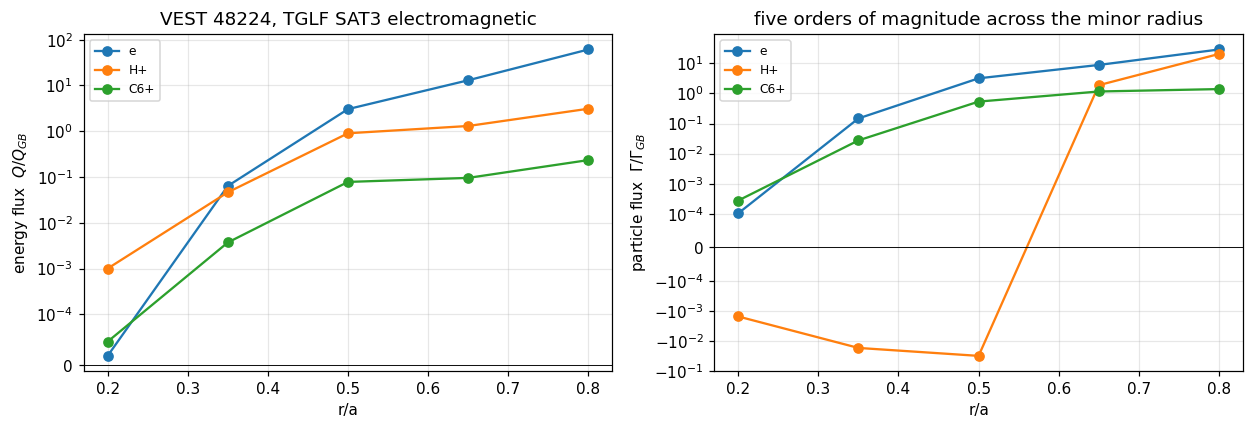

In [ ]:
solved = [rho for rho in RADII if RESULTS.get(rho) is not None and RESULTS[rho].ok] \
    if HAVE_RUN else []

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), sharex=True)
if solved:
    names = list(LOCALS[REFERENCE_RHO].names)
    for axis, channel, label in (
        (axes[0], "energy", "energy flux  $Q / Q_{GB}$"),
        (axes[1], "particle", "particle flux  $\\Gamma / \\Gamma_{GB}$"),
    ):
        for index, species in enumerate(names):
            axis.plot(
                solved,
                [RESULTS[rho].outputs_native.gbflux[channel][index] for rho in solved],
                "o-", label=species,
            )
        axis.set_xlabel("r/a")
        axis.set_ylabel(label)
        # The fluxes span five orders of magnitude between the innermost and
        # outermost surface, so a linear axis shows one point and hides four.
        # symlog keeps the zero line and the sign, which a log axis would drop.
        axis.set_yscale("symlog", linthresh=1e-4)
        axis.axhline(0.0, color="k", lw=0.6)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)
    axes[0].set_title(f"VEST 48224, TGLF SAT{SAT_RULE} electromagnetic")
    axes[1].set_title("five orders of magnitude across the minor radius")
else:
    for axis in axes:
        axis.text(0.5, 0.5, "Would show the gyro-Bohm energy and particle\nflux per"
                            " species across the five surfaces.",
                  ha="center", va="center", fontsize=9, transform=axis.transAxes)
        axis.set_axis_off()
fig.tight_layout()
plt.show()


## 8. What happens if you ask anyway

`run_surrogate` refuses by default. Obtaining an extrapolated number is a
deliberate act -- `allow_extrapolation=True` -- and the number comes back with
`qualified = False` and the audit attached, so that an extrapolated prediction and
an in-domain one are never interchangeable downstream.

The ensemble spread is the second signal. It is not a calibrated error bar, but it
is not blind either: the members agree where they were trained and diverge where
they were not. One warning about reading it -- `relative_spread()` is a ratio, so
it inflates without limit where a channel's mean crosses zero. The absolute spread
is printed beside it for that reason.

The control arm is upstream's own DIII-D sample, run through the *same*
feature-construction code. If the log transform, the key naming or the channel
order were wrong, that sample would not land inside its own training
distribution either.


In [ ]:
PREDICTION = None
if HAVE_AUDIT and HAVE_RUNTIME:
    identity, metadata = RESOLVED[REFERENCE_FAMILY]

    try:
        surrogate.run_surrogate(
            LOCALS[REFERENCE_RHO], REFERENCE_FAMILY, config=CONFIG
        )
        print("!! the model reported this plasma in domain, which contradicts"
              " section 4")
    except surrogate.TrainingDomainError as error:
        print("the default path refuses:\n")
        print(f"  {error}\n")

    # config=CONFIG matters even though SAT_RULE is not one of the model's input
    # channels: it is what lets the result record whether the rule the run asked
    # for is the rule the network was trained at.
    PREDICTION = surrogate.run_surrogate(
        LOCALS[REFERENCE_RHO], REFERENCE_FAMILY, config=CONFIG,
        allow_extrapolation=True,
    )
    spread = PREDICTION.relative_spread()
    print(f"asked again with allow_extrapolation=True  ->  qualified ="
          f" {PREDICTION.qualified}\n")
    print(f"  {'channel':12s} {'mean':>12s} {'absolute':>11s} {'relative':>9s}")
    for channel, value in PREDICTION.outputs.items():
        print(f"  {channel:12s} {value:+12.4g} {PREDICTION.uncertainty[channel]:11.4g}"
              f" {spread[channel] * 100:8.0f}%")
    print(f"\n  sat_rule_matches_model  "
          f"{PREDICTION.provenance['sat_rule_matches_model']}")

    # The control: upstream's own DIII-D case, through the same feature code.
    sample = Path(identity.directory).parent.parent / "test" / "data" / "sample_input.tglf"
    missing = ()
    keys = {}
    if sample.is_file():
        for line in sample.read_text(encoding="utf-8").splitlines():
            line = line.split("#")[0].strip()
            if "=" in line:
                key, _, raw = line.partition("=")
                try:
                    keys[key.strip()] = float(raw)
                except ValueError:
                    continue
        # Upstream's sample is upstream's file, and a model's channel set is the
        # model's: neither promises to cover the other, so check before indexing.
        stems = [n[: -len("_log10")] if n.endswith("_log10") else n
                 for n in metadata.xnames]
        missing = tuple(stem for stem in stems if stem not in keys)
    if sample.is_file() and not missing:
        features = np.array([
            np.log10(keys[stem]) if name.endswith("_log10") else keys[stem]
            for name, stem in zip(metadata.xnames, stems)
        ])
        z = (features - metadata.xm) / metadata.xsigma
        mean, sigma = surrogate.ensemble_predict(features, identity, metadata)
        control = {k: abs(sigma[k] / mean[k]) if mean[k] else float("inf") for k in mean}
        print(f"\n  {'':22s} {'max|z|':>7s}  relative spread")
        print(f"  {'upstream DIII-D sample':22s} {np.max(np.abs(z)):7.2f}"
              f"  {min(control.values()) * 100:.0f}-{max(control.values()) * 100:.0f}%")
        print(f"  {'VEST 48224':22s} {PREDICTION.domain.max_abs_z:7.2f}"
              f"  {min(spread.values()) * 100:.0f}-{max(spread.values()) * 100:.0f}%")
        print("\n  The same code, the same ensemble, one plasma it was trained on and"
              " one it was\n  not. The spread rises in every channel.")
    elif missing:
        print(f"\n  (upstream's sample_input.tglf sets no {', '.join(missing)}, which"
              f"\n   this family takes as input, so the in-domain control arm is"
              f" skipped)")
    else:
        print("\n  (upstream's own sample_input.tglf is not in this checkout, so the"
              "\n   in-domain control arm is skipped)")
elif HAVE_AUDIT:
    print("Would ask the best-matching family for a prediction, be refused, ask again"
          "\nwith allow_extrapolation=True, and compare the ensemble's disagreement on"
          "\nVEST with its disagreement on upstream's own DIII-D sample."
          "\n\nonnxruntime is absent: pip install 'vaft[surrogate]'.")
else:
    print("Would ask the best-matching family for a prediction and be refused.")

HAVE_PREDICTION = PREDICTION is not None


the default path refuses:

  refusing to predict outside the training distribution -- sat3_em_d3d+mastu+nstx_azf-1: 2 of 31 inputs beyond 3 sigma (TAUS_3 z=-4.5, TAUS_2 z=-4.4). The network will return finite numbers for this input; they are not grounded in anything it was trained on. Pass allow_extrapolation=True to obtain them anyway, and read `prediction.qualified` before using them.



asked again with allow_extrapolation=True  ->  qualified = False

  channel              mean    absolute  relative
  OUT_G_elec         +1.831       1.601       87%
  OUT_P_ions        +0.2804      0.6216      222%
  OUT_Q_elec         +3.353       4.607      137%
  OUT_Q_ions         +0.609       1.216      200%

  sat_rule_matches_model  True

                          max|z|  relative spread
  upstream DIII-D sample    1.50  26-59%
  VEST 48224                4.48  87-222%

  The same code, the same ensemble, one plasma it was trained on and one it was
  not. The spread rises in every channel.


## 9. The two backends, side by side

The surrogate's four output channels map onto TGLF's `gbflux` like this. One of
them does not mean what its name suggests, so the mapping is read out of
upstream's own unpacking code (`TurbulentTransport.jl`, `src/tglf_nn.jl`, where
the four-vector becomes a `FluxSolution`) rather than inferred:

| channel | is | native `gbflux` |
| --- | --- | --- |
| `OUT_G_elec` | electron particle flux | `gbflux["particle"][0]` |
| `OUT_P_ions` | **toroidal stress, i.e. momentum** -- not particle | `gbflux["momentum"]`, ions |
| `OUT_Q_elec` | electron energy flux | `gbflux["energy"][0]` |
| `OUT_Q_ions` | ion energy flux, summed over ions | `gbflux["energy"]`, ions |

**Read the difference below as extrapolation, not as surrogate accuracy.** The
surrogate is unqualified on this plasma, so the gap measures how far outside its
training set the input is -- not how well it reproduces TGLF. A fidelity
measurement needs an in-domain input, and issue #553 section 15 defers that
deliberately. VAFT itself states no mapping from these channels into an IDS until
section 14's `core_transport` projection lands.


In [ ]:
if HAVE_RUN and HAVE_PREDICTION and RESULTS[REFERENCE_RHO].ok:
    native = RESULTS[REFERENCE_RHO].outputs_native
    pairs = (
        ("OUT_G_elec", native.gbflux["particle"][0]),
        ("OUT_P_ions", float(np.sum(native.gbflux["momentum"][1:]))),
        ("OUT_Q_elec", native.gbflux["energy"][0]),
        ("OUT_Q_ions", float(np.sum(native.gbflux["energy"][1:]))),
    )
    print(f"at r/a = {REFERENCE_RHO}, SAT{SAT_RULE} electromagnetic\n")
    print(f"  {'channel':12s} {'native TGLF':>13s} {'surrogate':>13s}"
          f" {'+/-':>11s}")
    for channel, value in pairs:
        print(f"  {channel:12s} {value:+13.4g} {PREDICTION.outputs[channel]:+13.4g}"
              f" {PREDICTION.uncertainty[channel]:11.4g}")
    print(f"\n  surrogate qualified for this plasma: {PREDICTION.qualified}")
    print("  The left column is a result. The right column is a number.")
else:
    print("Would print the native and surrogate fluxes side by side at the reference"
          "\nsurface, with the surrogate marked unqualified -- which is the point of"
          " the\ncomparison rather than a caveat on it.")


at r/a = 0.5, SAT3 electromagnetic

  channel        native TGLF     surrogate         +/-
  OUT_G_elec           +3.18        +1.831       1.601
  OUT_P_ions       +0.007289       +0.2804      0.6216
  OUT_Q_elec          +3.038        +3.353       4.607
  OUT_Q_ions         +0.9792        +0.609       1.216

  surrogate qualified for this plasma: False
  The left column is a result. The right column is a number.


## 10. What this establishes

**It establishes that no public TGLF-NN model applies to VEST 48224, at any
radius audited.** Every family that can be evaluated is outside its training
distribution, and `TAUS` -- the ion-to-electron temperature ratio -- is in every
one of their violation sets. At r/a = 0.5 the best available family puts VEST 4.5
standard deviations out on that channel alone.

**It establishes that the reason is a property of the published corpus, not of
VAFT's conversion.** Upstream's own DIII-D sample lands inside the same family's
training distribution when pushed through the same feature-construction code in
section 8. A wrong log transform, key name or channel order would have put that
sample tens of sigma out too.

**It establishes that the refusal is over-determined.** The D3D, MAST-U and NSTX
families fail on the temperature ratio; the UKSTEP families fail an order of
magnitude harder on the impurity species, `AS_3` and `ZS_3`. Two independent
mismatches, so repairing either would not rescue the other.

**It does not establish VEST's turbulent transport.** The native fluxes here are
gyro-Bohm normalised, at five surfaces, at one time, under one saturation rule and
one electromagnetic setting, with an assumed effective charge. They are a
calculation of a model, not a measurement of a discharge, and nothing here
converts them to SI or compares them with an experimental power balance.

**It does not establish that a surrogate is unusable in principle.** It
establishes that *these artifacts* do not cover *this device*. A network trained
where the ions are cold would be a different statement entirely, and the audit
here is exactly the tool that would say so.

**It rests on four named assumptions**, all in section 0: the effective charge,
the impurity that carries it, where to truncate the grid, and the 3-sigma
threshold -- which is a proxy for containment rather than containment, because
`bounds_available` is `False` for every ONNX artifact upstream publishes.

Related: `neoclassical_transport_with_neo.ipynb` runs the neoclassical half of
the same kinetic state (issues #550, #553).


## 11. Cleanup

A TGLF run is small, but it goes to a temporary directory anyway, because the
inputs that produced it are in the repository and everything here can be
regenerated by re-running. To keep a run for inspection, comment out the
`close()` below; the path is printed in section 6.


In [ ]:
_cleanup.close()
print("done" if RUN_DIR is None else f"removed: {not RUN_DIR.exists()}")


removed: True
